# WiDS 2026 — Conservative Ensemble (v4)

**Why this notebook exists:** Notebook 03's stacking + isotonic calibration overfit on 221 training samples, dropping the leaderboard score from 0.96422 → 0.96234.

**This notebook applies four safer changes:**
1. Feature reduction via GBT permutation importance (less noise → less variance)
2. Constrained Optuna tuning (prevents memorising the 221-row training set)
3. Fixed manual ensemble weights (no meta-learner, no overfitting)
4. Optional Weibull AFT as a 4th parametric model (adds genuine diversity, can't overfit the survival curve shape)

**Four ensemble configurations are evaluated and submitted simultaneously** so you can pick the best one from the leaderboard without re-running.

## 0. Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter, WeibullAFTFitter
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.5f}'.format)

SEED            = 42
DATA_DIR        = 'Data/'
HORIZONS        = [12, 24, 48, 72]
BRIER_WEIGHTS   = {24: 0.3, 48: 0.4, 72: 0.3}

In [3]:
# ──────────────────────────────────────────────────────────────────
#  MAIN CONFIG  ← all decisions live here
# ──────────────────────────────────────────────────────────────────

# Feature selection: keep only top-K features by GBT importance
# Set to None to use all features
TOP_K_FEATURES = 15

# Optuna
OPTUNA_N_TRIALS = {'GBT': 50, 'RSF': 35, 'CoxPH': 25, 'WeibullAFT': 20}
OPTUNA_N_CV     = 5

# Four ensemble configurations to evaluate and submit
# Weights are normalised automatically — just set relative importance
ENSEMBLE_CONFIGS = {
    'A_GBT_only':  {'GBT': 1.00},
    'B_GBT_RSF':   {'GBT': 0.60, 'RSF': 0.40},
    'C_three':     {'GBT': 0.50, 'RSF': 0.35, 'CoxPH': 0.15},
    'D_with_AFT':  {'GBT': 0.45, 'RSF': 0.30, 'CoxPH': 0.15, 'WeibullAFT': 0.10},
}

# Default params (used if Optuna is skipped)
DEFAULT_PARAMS = {
    'GBT': {
        'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3,
        'subsample': 0.8, 'min_samples_leaf': 12, 'random_state': SEED,
    },
    'RSF': {
        'n_estimators': 300, 'min_samples_leaf': 12,
        'max_features': 'sqrt', 'n_jobs': -1, 'random_state': SEED,
    },
    'CoxPH':      {'penalizer': 0.1,  'l1_ratio': 0.05},
    'WeibullAFT': {'penalizer': 0.1,  'l1_ratio': 0.05},
}

N_CV_FOLDS = 5
print('Config loaded.')

Config loaded.


## 1. Data & Feature Engineering

In [4]:
train_raw = pd.read_csv(DATA_DIR + 'train.csv')
test_raw  = pd.read_csv(DATA_DIR + 'test.csv')

DROP_REDUNDANT = [
    'relative_growth_0_5h', 'area_growth_rate_ha_per_h',
    'centroid_displacement_m', 'centroid_speed_m_per_h',
    'closing_speed_m_per_h', 'projected_advance_m',
    'dist_slope_ci_0_5h', 'closing_speed_abs_m_per_h',
]
DROP_NOISE = [
    'event_start_hour', 'event_start_dayofweek', 'event_start_month',
    'along_track_speed', 'cross_track_component', 'dist_accel_m_per_h2',
]

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Baseline feature engineering only — no interaction terms."""
    df = df.copy()
    df['log1p_dist_min']    = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_under_5km']    = (df['dist_min_ci_0_5h'] < 5000).astype(int)
    df['is_growing']        = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['speed_x_alignment'] = df['radial_growth_rate_m_per_h'] * df['alignment_abs']
    drop = [c for c in DROP_REDUNDANT + DROP_NOISE if c in df.columns]
    df   = df.drop(columns=drop)
    meta = [c for c in ['event_id', 'time_to_hit_hours', 'event'] if c in df.columns]
    return df.drop(columns=meta)


X_all   = build_features(train_raw)
X_test_all = build_features(test_raw)
y_event = train_raw['event'].values.astype(bool)
y_time  = train_raw['time_to_hit_hours'].values

print(f'Full feature set: {X_all.shape[1]} features')
print(X_all.columns.tolist())

Full feature set: 24 features
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'log1p_dist_min', 'dist_under_5km', 'is_growing', 'speed_x_alignment']


## 2. Metrics & Model Wrappers

In [5]:
def brier_at_horizon(ye, yt, pred, H):
    mask  = ~((ye == 0) & (yt < H))
    y_obs = ((ye == 1) & (yt <= H)).astype(float)
    return float(np.mean((y_obs[mask] - pred[mask]) ** 2))

def weighted_brier(ye, yt, pd_):
    return sum(w * brier_at_horizon(ye, yt, pd_[H], H) for H, w in BRIER_WEIGHTS.items())

def cindex(ye, yt, risk):
    return concordance_index_censored(ye.astype(bool), yt, risk)[0]

def hybrid(ci, wb):
    return 0.3 * ci + 0.7 * (1.0 - wb)

def evaluate(ye, yt, pd_, label=''):
    ci = cindex(ye, yt, pd_[24])
    wb = weighted_brier(ye, yt, pd_)
    return {'Model': label, 'C-index': ci,
            **{f'B@{H}h': brier_at_horizon(ye, yt, pd_[H], H) for H in HORIZONS},
            'W-Brier': wb, 'Hybrid': hybrid(ci, wb)}

def enforce_monotonicity(pd_):
    mat = np.column_stack([pd_[H] for H in HORIZONS]).clip(0, 1)
    mat = np.maximum.accumulate(mat, axis=1)
    return {H: mat[:, i] for i, H in enumerate(HORIZONS)}

print('Metrics defined.')

Metrics defined.


In [6]:
def _safe_eval(fn, t):
    return float(fn(float(np.clip(t, fn.x[0], fn.x[-1]))))


class CoxPHWrapper:
    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer; self.l1_ratio = l1_ratio
        self.scaler = StandardScaler(); self.model = None

    def fit(self, X, ye, yt):
        Xs = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        self.model = CoxPHFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(Xs.assign(duration=yt, event=ye.astype(int)),
                       duration_col='duration', event_col='event')
        return self

    def predict_survival_probs(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        S  = self.model.predict_survival_function(Xs, times=HORIZONS).values.T
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        return self.model.predict_partial_hazard(Xs).values

    def feature_importances(self, cols):
        return self.model.params_.abs().sort_values(ascending=False)


class WeibullAFTWrapper:
    """Parametric survival model — can't overfit the survival curve shape."""
    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer; self.l1_ratio = l1_ratio
        self.scaler = StandardScaler(); self.model = None

    def fit(self, X, ye, yt):
        Xs = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        self.model = WeibullAFTFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(Xs.assign(duration=yt, event=ye.astype(int)),
                       duration_col='duration', event_col='event')
        return self

    def predict_survival_probs(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        S  = self.model.predict_survival_function(Xs, times=HORIZONS).values.T
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        # Shorter predicted median = more urgent = higher risk score
        return -self.model.predict_median(Xs).values.ravel()

    def feature_importances(self, cols):
        # Weibull AFT has two sub-models (lambda_, rho_); combine by abs value
        try:
            lam = self.model.params_['lambda_'].abs()
            rho = self.model.params_['rho_'].abs()
            combined = (lam + rho.reindex(lam.index, fill_value=0)).sort_values(ascending=False)
            return combined
        except Exception:
            return pd.Series(dtype=float)


class RSFWrapper:
    def __init__(self, **params):
        self.model = RandomSurvivalForest(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)

    def feature_importances(self, cols):
        return pd.Series(self.model.feature_importances_, index=cols).sort_values(ascending=False)


class GBTWrapper:
    def __init__(self, **params):
        self.model = GradientBoostingSurvivalAnalysis(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)

    def feature_importances(self, cols):
        return pd.Series(self.model.feature_importances_, index=cols).sort_values(ascending=False)


def build_model(name, params):
    if name == 'CoxPH':      return CoxPHWrapper(**params)
    if name == 'WeibullAFT': return WeibullAFTWrapper(**params)
    if name == 'RSF':        return RSFWrapper(**params)
    if name == 'GBT':        return GBTWrapper(**params)
    raise ValueError(f'Unknown model: {name}')

print('Model wrappers defined.')

Model wrappers defined.


## 3. Feature Selection via GBT Permutation Importance

We rank features by how much the hybrid score drops when each feature is randomly shuffled. Only the top-K are kept for all subsequent modeling. This reduces variance in tree splits without losing the most informative signal.

In [7]:
def permutation_importance_survival(model_params, X, ye, yt,
                                    n_repeats=5, n_cv=5):
    """
    Estimate feature importance by permuting each feature and measuring
    the mean drop in hybrid score across CV folds.
    Returns a Series sorted by importance (highest first).
    """
    skf  = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=SEED)
    cols = X.columns.tolist()

    # Baseline OOF hybrid score
    baseline_scores = []
    fold_preds = []   # save predictions to avoid re-fitting for each feature
    fold_truths = []

    for tr, val in skf.split(X, ye):
        m = build_model('GBT', model_params)
        m.fit(X.iloc[tr], ye[tr], yt[tr])
        pd_ = m.predict_survival_probs(X.iloc[val])
        row = evaluate(ye[val], yt[val], pd_)
        baseline_scores.append(row['Hybrid'])
        fold_preds.append((m, val, tr))
        fold_truths.append((ye[val], yt[val]))

    baseline = np.mean(baseline_scores)
    print(f'Baseline GBT CV Hybrid: {baseline:.5f}')

    importances = {}
    for feat in cols:
        drops = []
        for rep in range(n_repeats):
            rep_scores = []
            rng = np.random.default_rng(SEED + rep)
            for (m, val, _), (ye_val, yt_val) in zip(fold_preds, fold_truths):
                X_perm         = X.iloc[val].copy()
                X_perm[feat]   = rng.permutation(X_perm[feat].values)
                pd_p           = m.predict_survival_probs(X_perm)
                rep_scores.append(evaluate(ye_val, yt_val, pd_p)['Hybrid'])
            drops.append(baseline - np.mean(rep_scores))
        importances[feat] = np.mean(drops)

    return pd.Series(importances).sort_values(ascending=False)


print('Running permutation importance (this takes ~2 minutes)...')
perm_imp = permutation_importance_survival(DEFAULT_PARAMS['GBT'],
                                           X_all, y_event, y_time,
                                           n_repeats=5, n_cv=N_CV_FOLDS)

print('\nPermutation importance (drop in Hybrid when shuffled):')
print(perm_imp.round(5))

Running permutation importance (this takes ~2 minutes)...
Baseline GBT CV Hybrid: 0.97413

Permutation importance (drop in Hybrid when shuffled):
dist_min_ci_0_5h                0.03294
dist_under_5km                  0.02456
log1p_dist_min                  0.01515
num_perimeters_0_5h             0.00236
dt_first_last_0_5h              0.00090
area_first_ha                   0.00059
log1p_area_first                0.00052
alignment_cos                   0.00013
spread_bearing_sin              0.00001
radial_growth_m                 0.00000
radial_growth_rate_m_per_h      0.00000
log_area_ratio_0_5h             0.00000
log1p_growth                    0.00000
dist_std_ci_0_5h                0.00000
dist_change_ci_0_5h             0.00000
dist_fit_r2_0_5h                0.00000
area_growth_rel_0_5h            0.00000
area_growth_abs_0_5h            0.00000
is_growing                      0.00000
speed_x_alignment               0.00000
spread_bearing_cos             -0.00000
spread_bearing

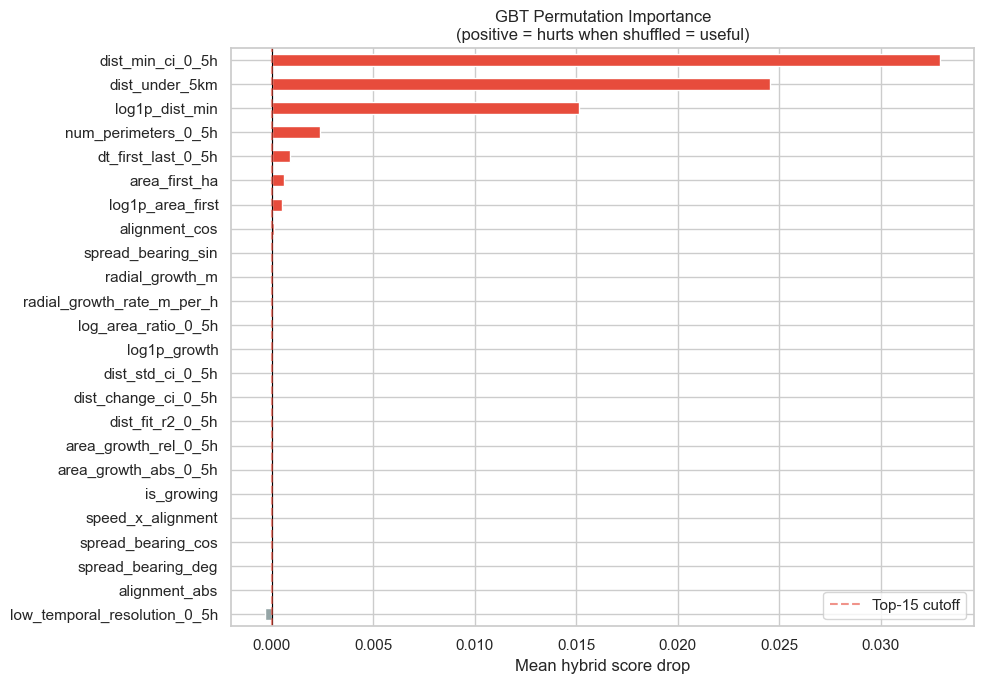

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e74c3c' if v > 0 else '#95a5a6' for v in perm_imp.values]
perm_imp.plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('GBT Permutation Importance\n(positive = hurts when shuffled = useful)',
             fontsize=12)
ax.set_xlabel('Mean hybrid score drop')
if TOP_K_FEATURES is not None:
    cutoff = perm_imp.iloc[TOP_K_FEATURES - 1] if TOP_K_FEATURES <= len(perm_imp) else 0
    ax.axvline(cutoff, color='#e74c3c', ls='--', alpha=0.6,
               label=f'Top-{TOP_K_FEATURES} cutoff')
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Select top-K features ──
if TOP_K_FEATURES is not None:
    # Keep features with positive importance, up to TOP_K_FEATURES
    positive_imp = perm_imp[perm_imp > 0]
    n_keep       = min(TOP_K_FEATURES, len(positive_imp))
    SELECTED_FEATURES = perm_imp.head(n_keep).index.tolist()
else:
    SELECTED_FEATURES = X_all.columns.tolist()

X_train = X_all[SELECTED_FEATURES]
X_test  = X_test_all[SELECTED_FEATURES]

print(f'Selected {len(SELECTED_FEATURES)} features:')
print(SELECTED_FEATURES)
print(f'\nDropped: {[c for c in X_all.columns if c not in SELECTED_FEATURES]}')

Selected 9 features:
['dist_min_ci_0_5h', 'dist_under_5km', 'log1p_dist_min', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'area_first_ha', 'log1p_area_first', 'alignment_cos', 'spread_bearing_sin']

Dropped: ['low_temporal_resolution_0_5h', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'spread_bearing_deg', 'spread_bearing_cos', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_fit_r2_0_5h', 'alignment_abs', 'is_growing', 'speed_x_alignment']


## 4. Constrained Optuna Tuning

Search spaces are deliberately conservative: larger `min_samples_leaf`, shallower `max_depth`, higher `subsample`. This prevents the models from memorising the small training set.

In [10]:
def conservative_search_space(name, trial):
    """Constrained search spaces that prevent overfitting on 221 samples."""
    if name == 'GBT':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'max_depth':        trial.suggest_int('max_depth', 2, 4),        # ← capped at 4
            'subsample':        trial.suggest_float('subsample', 0.7, 1.0),  # ← min 0.7
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 30), # ← min 10
            'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
            'random_state':     SEED,
        }
    elif name == 'RSF':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 600),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 25), # ← min 10
            'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
            'n_jobs': -1, 'random_state': SEED,
        }
    elif name == 'CoxPH':
        return {
            'penalizer': trial.suggest_float('penalizer', 0.05, 1.0, log=True),
            'l1_ratio':  trial.suggest_float('l1_ratio', 0.0, 0.3),
        }
    elif name == 'WeibullAFT':
        return {
            'penalizer': trial.suggest_float('penalizer', 0.05, 1.0, log=True),
            'l1_ratio':  trial.suggest_float('l1_ratio', 0.0, 0.3),
        }


def make_objective(name, X, ye, yt):
    skf = StratifiedKFold(n_splits=OPTUNA_N_CV, shuffle=True, random_state=SEED)
    def objective(trial):
        params = conservative_search_space(name, trial)
        scores = []
        for tr, val in skf.split(X, ye):
            try:
                m = build_model(name, params)
                m.fit(X.iloc[tr], ye[tr], yt[tr])
                pd_ = m.predict_survival_probs(X.iloc[val])
                scores.append(evaluate(ye[val], yt[val], pd_)['Hybrid'])
            except Exception:
                return 0.0
        return float(np.mean(scores))
    return objective


print('Optuna objective factory defined.')

Optuna objective factory defined.


In [11]:
# Determine which models are needed across all ensemble configs
all_needed_models = set()
for cfg in ENSEMBLE_CONFIGS.values():
    all_needed_models.update(cfg.keys())

TUNED_PARAMS = dict(DEFAULT_PARAMS)  # start from defaults
studies      = {}

for name in all_needed_models:
    n_trials = OPTUNA_N_TRIALS.get(name, 25)
    print(f'Tuning {name} ({n_trials} trials)...')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(name, X_train, y_event, y_time),
                   n_trials=n_trials, show_progress_bar=True)

    best = study.best_params.copy()
    if name in ('RSF', 'GBT'):  best.update({'random_state': SEED})
    if name == 'RSF':           best['n_jobs'] = -1
    TUNED_PARAMS[name] = best
    studies[name]      = study
    print(f'  Best CV Hybrid: {study.best_value:.5f}  |  params: {best}\n')

Tuning CoxPH (25 trials)...


Best trial: 14. Best value: 0.971066: 100%|██████████| 25/25 [00:06<00:00,  3.78it/s]


  Best CV Hybrid: 0.97107  |  params: {'penalizer': 0.05284492055106611, 'l1_ratio': 0.0039530197390021116}

Tuning WeibullAFT (20 trials)...


Best trial: 14. Best value: 0.971395: 100%|██████████| 20/20 [00:13<00:00,  1.51it/s]


  Best CV Hybrid: 0.97139  |  params: {'penalizer': 0.05284492055106611, 'l1_ratio': 0.11388127302606703}

Tuning RSF (35 trials)...


Best trial: 32. Best value: 0.975632: 100%|██████████| 35/35 [00:23<00:00,  1.48it/s]


  Best CV Hybrid: 0.97563  |  params: {'n_estimators': 311, 'min_samples_leaf': 17, 'max_features': 0.5, 'random_state': 42, 'n_jobs': -1}

Tuning GBT (50 trials)...


Best trial: 27. Best value: 0.97699: 100%|██████████| 50/50 [00:20<00:00,  2.46it/s]

  Best CV Hybrid: 0.97699  |  params: {'n_estimators': 362, 'learning_rate': 0.08535071943827773, 'max_depth': 3, 'subsample': 0.9188840261236977, 'min_samples_leaf': 24, 'max_features': 0.5, 'random_state': 42}



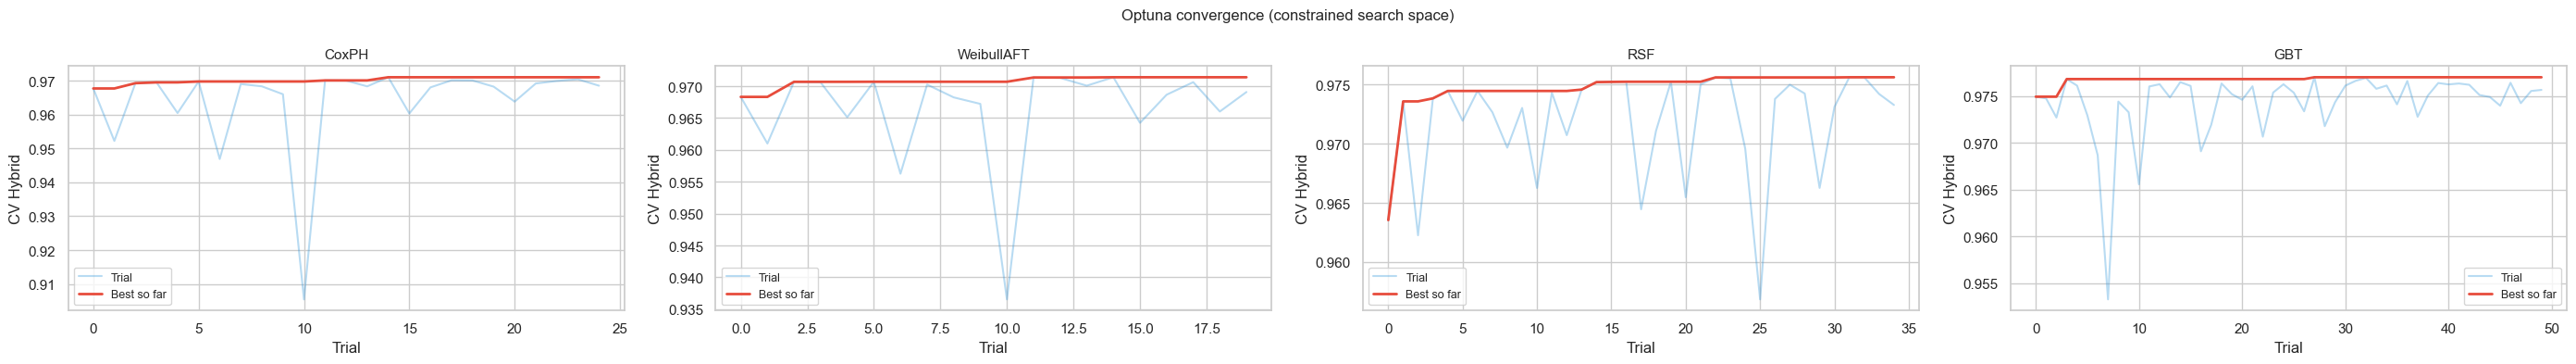

In [12]:
# ── Optuna convergence plots ──
n = len(studies)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 4))
if n == 1: axes = [axes]

for ax, (name, study) in zip(axes, studies.items()):
    vals    = [t.value for t in study.trials if t.value]
    best_so = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.35, color='#3498db', label='Trial')
    ax.plot(best_so, color='#e74c3c', lw=2, label='Best so far')
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('Trial'); ax.set_ylabel('CV Hybrid')
    ax.legend(fontsize=9)

plt.suptitle('Optuna convergence (constrained search space)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. CV Evaluation of All Ensemble Configurations

In [13]:
def weighted_ensemble(model_probs: dict, weights: dict) -> dict:
    """Normalised weighted average of survival probabilities."""
    total = sum(weights.values())
    combined = {H: sum(model_probs[n][H] * (weights[n] / total)
                       for n in weights) for H in HORIZONS}
    return enforce_monotonicity(combined)


def cv_evaluate_config(config_name: str, weight_dict: dict,
                        X, ye, yt, n_splits=N_CV_FOLDS):
    """
    Run K-fold CV for a given ensemble configuration.
    Returns mean scores and per-fold details.
    """
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []

    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        model_probs = {}
        for name in weight_dict:
            try:
                m = build_model(name, TUNED_PARAMS[name])
                m.fit(X.iloc[tr], ye[tr], yt[tr])
                model_probs[name] = m.predict_survival_probs(X.iloc[val])
            except Exception as e:
                print(f'  Warning: {name} fold-{fold} failed ({e}), using zeros')
                model_probs[name] = {H: np.zeros(len(val)) for H in HORIZONS}

        ensemble_p = weighted_ensemble(model_probs, weight_dict)
        row        = evaluate(ye[val], yt[val], ensemble_p)
        row['Fold'] = fold
        rows.append(row)

    df   = pd.DataFrame(rows)
    mean = df[['C-index','W-Brier','Hybrid']].mean()
    std  = df[['C-index','W-Brier','Hybrid']].std()
    print(f'  {config_name:<18}: '
          f'Hybrid={mean["Hybrid"]:.5f} ± {std["Hybrid"]:.5f}  '
          f'C-index={mean["C-index"]:.4f}  W-Brier={mean["W-Brier"]:.4f}')
    return mean.to_dict(), df


print('Running CV for all ensemble configurations...')
print('=' * 75)

cv_results  = {}   # config_name -> mean score dict
cv_fold_dfs = {}   # config_name -> per-fold DataFrame

for cfg_name, weights in ENSEMBLE_CONFIGS.items():
    mean_scores, fold_df = cv_evaluate_config(
        cfg_name, weights, X_train, y_event, y_time)
    cv_results[cfg_name]  = mean_scores
    cv_fold_dfs[cfg_name] = fold_df

print('=' * 75)

Running CV for all ensemble configurations...
  A_GBT_only        : Hybrid=0.97699 ± 0.01259  C-index=0.9529  W-Brier=0.0127
  B_GBT_RSF         : Hybrid=0.97732 ± 0.01210  C-index=0.9551  W-Brier=0.0132
  C_three           : Hybrid=0.97601 ± 0.01158  C-index=0.9514  W-Brier=0.0135
  D_with_AFT        : Hybrid=0.97597 ± 0.01226  C-index=0.9518  W-Brier=0.0137


In [14]:
# ── Comparison table ──
comp_df = pd.DataFrame(cv_results).T[['C-index','W-Brier','Hybrid']]
comp_df['Weight config'] = [str(ENSEMBLE_CONFIGS[k]) for k in comp_df.index]

def green_shade(s):
    norm = (s - s.min()) / (s.max() - s.min() + 1e-9)
    return [f'background-color: rgba(46,204,113,{v:.2f})' for v in norm]

print('=== CV COMPARISON — All Ensemble Configurations ===')
comp_df.style.apply(green_shade, subset=['Hybrid'])

=== CV COMPARISON — All Ensemble Configurations ===


,C-index,W-Brier,Hybrid,Weight config
A_GBT_only,0.952929,0.012698,0.976990,{'GBT': 1.0}
B_GBT_RSF,0.955140,0.013176,0.977319,"{'GBT': 0.6, 'RSF': 0.4}"
C_three,0.951423,0.013453,0.976010,"{'GBT': 0.5, 'RSF': 0.35, 'CoxPH': 0.15}"
D_with_AFT,0.951785,0.013669,0.975967,"{'GBT': 0.45, 'RSF': 0.3, 'CoxPH': 0.15, 'WeibullAFT': 0.1}"


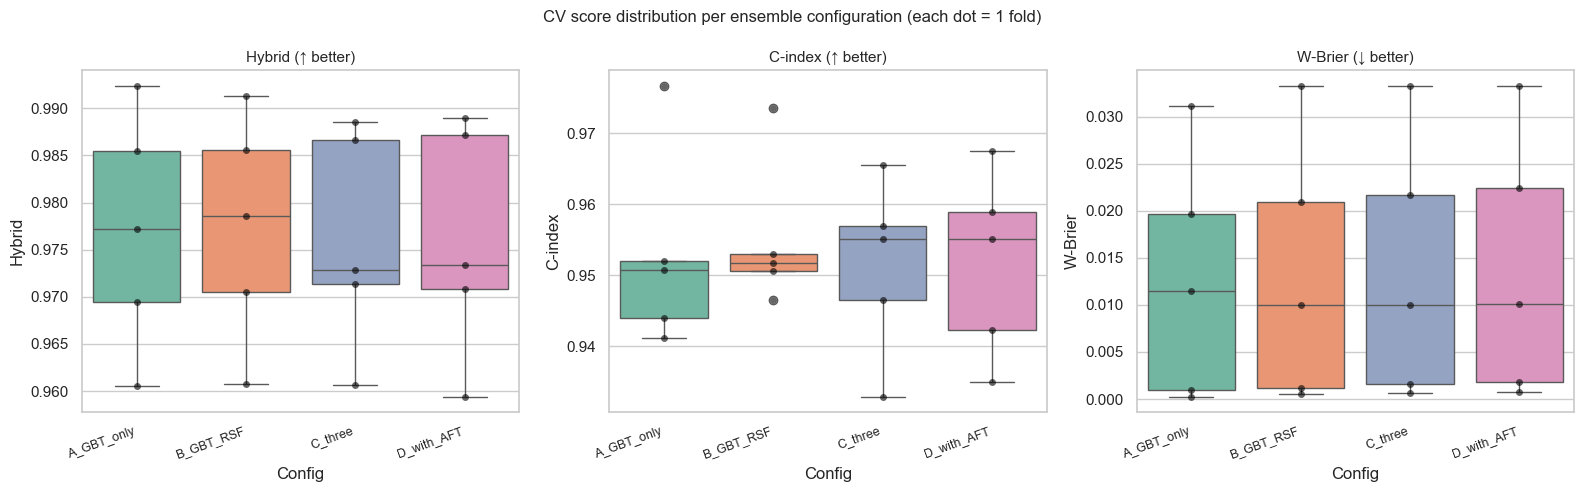

In [15]:
# ── Per-fold boxplot ──
all_fold_data = []
for cfg_name, fold_df in cv_fold_dfs.items():
    for _, row in fold_df.iterrows():
        all_fold_data.append({'Config': cfg_name, 'Hybrid': row['Hybrid'],
                               'C-index': row['C-index'], 'W-Brier': row['W-Brier']})
plot_df = pd.DataFrame(all_fold_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['Hybrid', 'C-index', 'W-Brier']):
    order = list(ENSEMBLE_CONFIGS.keys())
    sns.boxplot(data=plot_df, x='Config', y=metric, order=order,
                palette='Set2', ax=ax)
    sns.stripplot(data=plot_df, x='Config', y=metric, order=order,
                  color='black', size=5, alpha=0.6, ax=ax, jitter=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    note = '↑ better' if metric in ['Hybrid','C-index'] else '↓ better'
    ax.set_title(f'{metric} ({note})', fontsize=11)

plt.suptitle('CV score distribution per ensemble configuration (each dot = 1 fold)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# ── Which config is best? ──
best_cfg = max(cv_results, key=lambda k: cv_results[k]['Hybrid'])
print(f'Best configuration by CV Hybrid Score: {best_cfg}')
print(f"  Hybrid = {cv_results[best_cfg]['Hybrid']:.5f}")
print(f"  Weights: {ENSEMBLE_CONFIGS[best_cfg]}")
print()
print('All configs ranked:')
for cfg, s in sorted(cv_results.items(), key=lambda x: -x[1]['Hybrid']):
    print(f"  {cfg:<20} Hybrid={s['Hybrid']:.5f}")

Best configuration by CV Hybrid Score: B_GBT_RSF
  Hybrid = 0.97732
  Weights: {'GBT': 0.6, 'RSF': 0.4}

All configs ranked:
  B_GBT_RSF            Hybrid=0.97732
  A_GBT_only           Hybrid=0.97699
  C_three              Hybrid=0.97601
  D_with_AFT           Hybrid=0.97597


## 6. Final Predictions — All Configurations

All four submission files are generated so you can upload each to the leaderboard and compare without re-running the notebook.

In [17]:
# ── Retrain all needed models on the full training set ──
final_models = {}
for name in all_needed_models:
    m = build_model(name, TUNED_PARAMS[name])
    m.fit(X_train, y_event, y_time)
    final_models[name] = m
    print(f'{name}: fitted on full train set.')

CoxPH: fitted on full train set.
WeibullAFT: fitted on full train set.
RSF: fitted on full train set.
GBT: fitted on full train set.


In [18]:
# ── Per-model test predictions ──
test_model_probs = {name: final_models[name].predict_survival_probs(X_test)
                    for name in all_needed_models}

# ── Generate one submission file per config ──
sample = pd.read_csv(DATA_DIR + 'sample_submission.csv')
submissions = {}

for cfg_name, weights in ENSEMBLE_CONFIGS.items():
    probs = weighted_ensemble(
        {n: test_model_probs[n] for n in weights}, weights)

    # Verify monotonicity
    for i in range(len(X_test)):
        p = [probs[H][i] for H in HORIZONS]
        assert p == sorted(p), f'Monotonicity violated at row {i} in {cfg_name}'

    sub = pd.DataFrame({
        'event_id': test_raw['event_id'].values,
        'prob_12h': probs[12],
        'prob_24h': probs[24],
        'prob_48h': probs[48],
        'prob_72h': probs[72],
    })
    assert list(sub.columns)    == list(sample.columns)
    assert set(sub['event_id']) == set(sample['event_id'])

    fname = f'submission_{cfg_name}.csv'
    sub.to_csv(fname, index=False)
    submissions[cfg_name] = sub
    print(f'Saved {fname}')

print('\nAll submission files generated.')

Saved submission_A_GBT_only.csv
Saved submission_B_GBT_RSF.csv
Saved submission_C_three.csv
Saved submission_D_with_AFT.csv

All submission files generated.


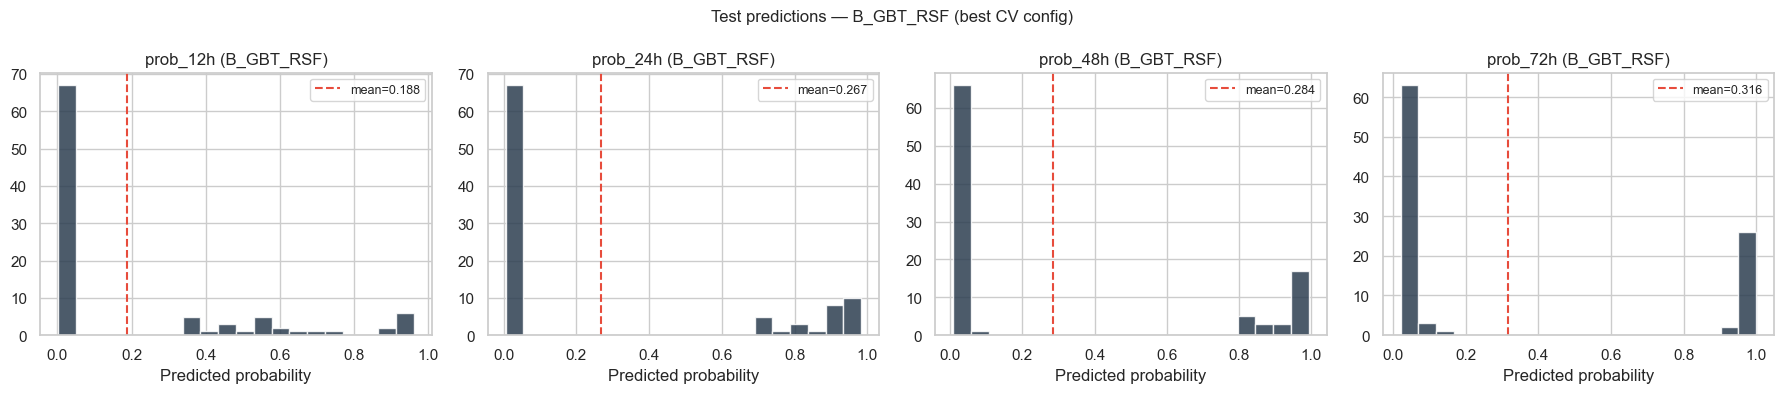

In [19]:
# ── Distribution of test predictions (best CV config) ──
best_probs = weighted_ensemble(
    {n: test_model_probs[n] for n in ENSEMBLE_CONFIGS[best_cfg]},
    ENSEMBLE_CONFIGS[best_cfg])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, H in zip(axes, HORIZONS):
    ax.hist(best_probs[H], bins=20, color='#2c3e50', edgecolor='white', alpha=0.85)
    ax.axvline(best_probs[H].mean(), color='#e74c3c', ls='--',
               label=f'mean={best_probs[H].mean():.3f}')
    ax.set_title(f'prob_{H}h ({best_cfg})')
    ax.set_xlabel('Predicted probability')
    ax.legend(fontsize=9)
plt.suptitle(f'Test predictions — {best_cfg} (best CV config)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Feature Importance Comparison Across Final Models

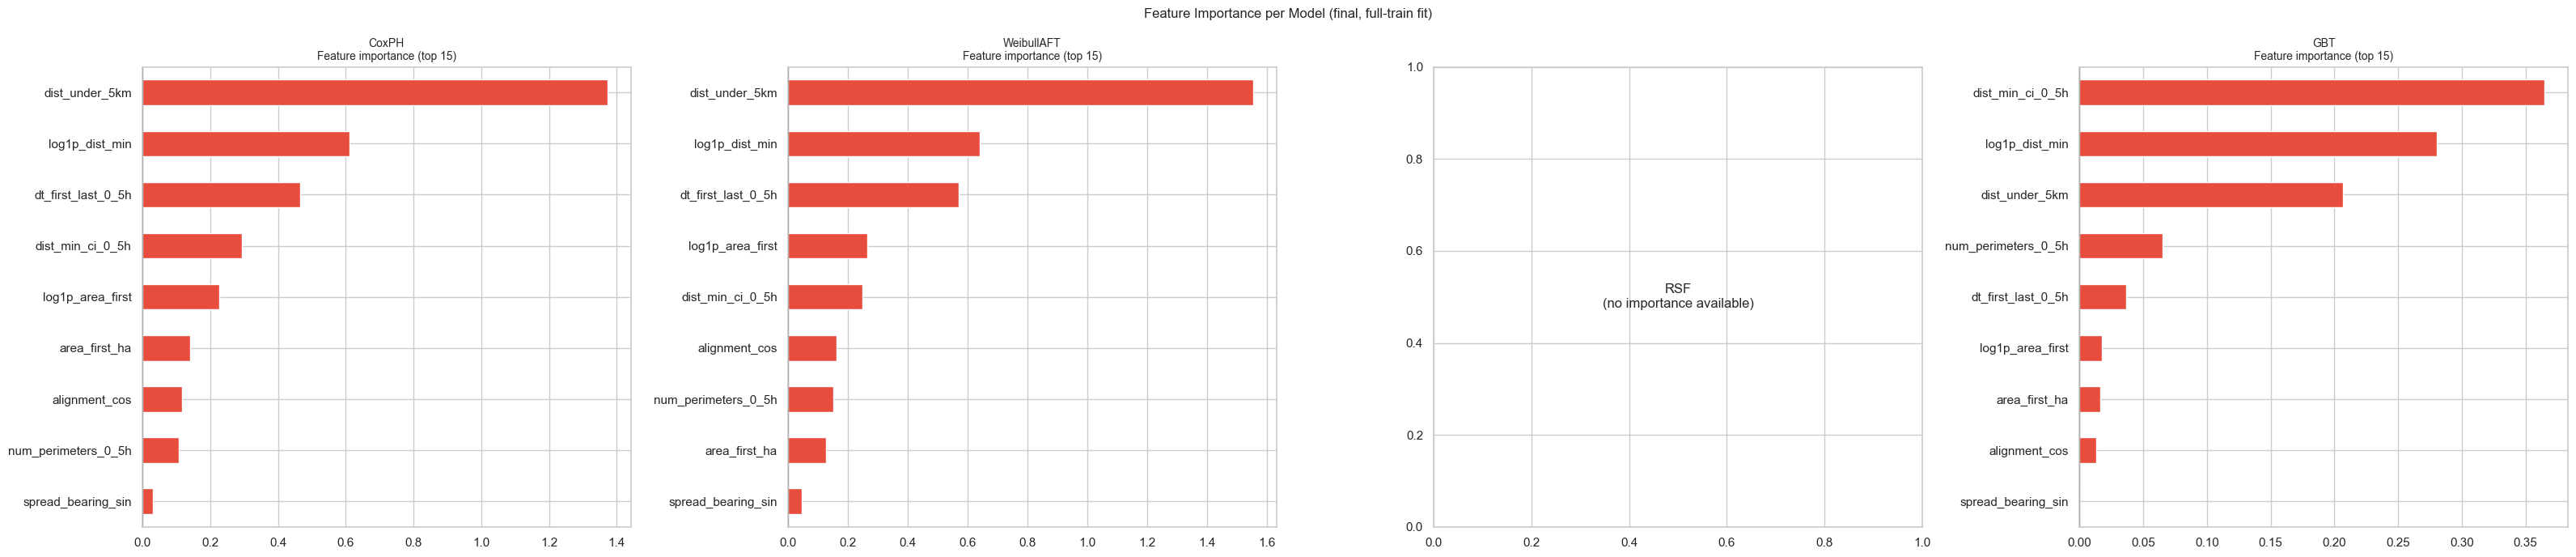

In [20]:
n_models = len(final_models)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 7))
if n_models == 1: axes = [axes]

for ax, (name, m) in zip(axes, final_models.items()):
    try:
        imp = m.feature_importances(X_train.columns)
        # For WeibullAFT, filter to only selected features
        imp = imp.reindex(X_train.columns).dropna().sort_values(ascending=False).head(15)
        colors = ['#e74c3c' if v >= 0 else '#3498db' for v in imp.values]
        imp.plot(kind='barh', ax=ax, color=colors)
        ax.invert_yaxis()
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(f'{name}\nFeature importance (top 15)', fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, f'{name}\n(no importance available)', ha='center', va='center')

plt.suptitle('Feature Importance per Model (final, full-train fit)', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# ── Final summary ──
print('=' * 68)
print('  NOTEBOOK 04 SUMMARY')
print('=' * 68)
print(f'  Features used     : {len(SELECTED_FEATURES)} (top-{TOP_K_FEATURES} by permutation importance)')
print(f'  Selected features : {SELECTED_FEATURES}')
print()
print('  Tuned parameters:')
for name in all_needed_models:
    print(f'    {name:<14}: {TUNED_PARAMS[name]}')
print()
print('  CV scores (5-fold, unbiased):')
for cfg, s in sorted(cv_results.items(), key=lambda x: -x[1]['Hybrid']):
    print(f'    {cfg:<20} Hybrid={s["Hybrid"]:.5f}  '
          f'C-index={s["C-index"]:.4f}  W-Brier={s["W-Brier"]:.4f}')
print()
print('  Submission files generated:')
for cfg in ENSEMBLE_CONFIGS:
    marker = ' ← best CV' if cfg == best_cfg else ''
    print(f'    submission_{cfg}.csv{marker}')
print('=' * 68)

  NOTEBOOK 04 SUMMARY
  Features used     : 9 (top-15 by permutation importance)
  Selected features : ['dist_min_ci_0_5h', 'dist_under_5km', 'log1p_dist_min', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'area_first_ha', 'log1p_area_first', 'alignment_cos', 'spread_bearing_sin']

  Tuned parameters:
    CoxPH         : {'penalizer': 0.05284492055106611, 'l1_ratio': 0.0039530197390021116}
    WeibullAFT    : {'penalizer': 0.05284492055106611, 'l1_ratio': 0.11388127302606703}
    RSF           : {'n_estimators': 311, 'min_samples_leaf': 17, 'max_features': 0.5, 'random_state': 42, 'n_jobs': -1}
    GBT           : {'n_estimators': 362, 'learning_rate': 0.08535071943827773, 'max_depth': 3, 'subsample': 0.9188840261236977, 'min_samples_leaf': 24, 'max_features': 0.5, 'random_state': 42}

  CV scores (5-fold, unbiased):
    B_GBT_RSF            Hybrid=0.97732  C-index=0.9551  W-Brier=0.0132
    A_GBT_only           Hybrid=0.97699  C-index=0.9529  W-Brier=0.0127
    C_three              Hyb